# import Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"DataSet/powerplant_data.csv")

In [3]:
df = pd.DataFrame(data)
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT = Temperature
# V = Vacuum
# AP = Pressure
# RH = Humidity
# PE = Produce Energy

In [5]:
X = df.drop("PE",axis=1)
y=df["PE"]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [7]:
X_train ,X_test, Y_train, Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler=scaler.transform(X_test)

# Convert Into Tensor

In [25]:
import torch.nn as nn
import torch

In [26]:
X_train_tensor = torch.tensor(X_train_scaler , dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaler , dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train.values , dtype=torch.float32).view(-1,1)
Y_test_tensor = torch.tensor(Y_test.values , dtype=torch.float32).view(-1,1)

In [30]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor,Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,Y_test_tensor)

## data convert in to Batch

In [34]:
train_loder = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loder = DataLoader(test_dataset,batch_size=32)

# define the Model

In [31]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(

            #1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Out Put Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [33]:
import torch.optim as optim

model = ANN()  # creatre the object of the model|

#loss Optimizer 

crietron = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

## Train the model

In [45]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epoch = 100

#training

for epoch in range(epoch):
    model.train()
    running_loss = 0.0
    for xb,yb in train_loder:
        optimizer.zero_grad()

        output = model(xb)
        loss = crietron(output,yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loder)
    train_losses.append(epoch_train_loss)

#validation

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb,yb in test_loder:
            output = model(xb)
            loss = crietron(output,yb)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loder)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epoch}==>Train Loss ==> {epoch_train_loss} & val Loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

epoch 1/0==>Train Loss ==> 20.482150693734486 & val Loss = 20.251768112182617
epoch 2/1==>Train Loss ==> 20.464214138189952 & val Loss = 19.58997917175293
epoch 3/2==>Train Loss ==> 20.47543214559555 & val Loss = 18.74744987487793
epoch 4/3==>Train Loss ==> 20.43701837062836 & val Loss = 18.813480377197266
epoch 5/4==>Train Loss ==> 20.548377041021983 & val Loss = 18.55021095275879
epoch 6/5==>Train Loss ==> 20.479598234097164 & val Loss = 18.88811492919922
epoch 7/6==>Train Loss ==> 20.45784547130267 & val Loss = 18.562788009643555
epoch 8/7==>Train Loss ==> 20.368058806657793 & val Loss = 19.07193946838379
epoch 9/8==>Train Loss ==> 20.390061342716216 & val Loss = 18.605886459350586
epoch 10/9==>Train Loss ==> 20.561372462908427 & val Loss = 18.62256622314453
epoch 11/10==>Train Loss ==> 20.464298899968465 & val Loss = 18.694067001342773
epoch 12/11==>Train Loss ==> 20.488499814271925 & val Loss = 18.884645462036133
epoch 13/12==>Train Loss ==> 20.55002966324488 & val Loss = 18.56194

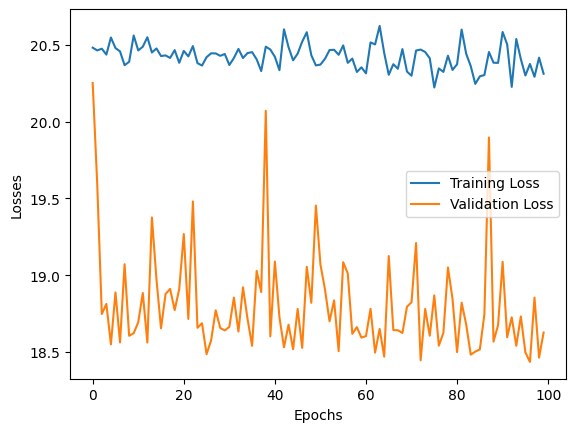

In [54]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()